# EDA 04 — Bivariate Analysis (Feature × Target)

For each feature, how does the pass/fail rate change?
This is the most actionable EDA notebook — it tells us which features
are worth engineering and encoding for modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from helpers.data_loader import DataLoader

pd.set_option('display.max_columns', 120)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

TARGET = 'Results'
T_COLORS = {'Pass': '#2ecc71', 'Fail': '#e74c3c', 'Pass w/ Conditions': '#f39c12'}
PALETTE = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

df = pd.read_parquet(DataLoader.processed('train.parquet'))
df['Inspection Date'] = pd.to_datetime(df['Inspection Date'], errors='coerce')
print('Train shape:', df.shape)

Train shape: (137176, 26)


## Helper: pass/fail rate by category

In [2]:
def pass_rate_by(col: str, top_n: int = 15, min_count: int = 100):
    """Stacked bar chart of Results distribution by category."""
    # Filter to categories with enough data
    vc = df[col].value_counts()
    keep = vc[vc >= min_count].index[:top_n]
    sub = df[df[col].isin(keep)]

    ct = pd.crosstab(sub[col], sub[TARGET], normalize='index').mul(100)
    # Sort by pass rate
    if 'Pass' in ct.columns:
        ct = ct.sort_values('Pass', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, len(ct) * 0.35)))
    ordered_cols = [c for c in ['Pass', 'Pass w/ Conditions', 'Fail'] if c in ct.columns]
    colors = [T_COLORS.get(c, '#95a5a6') for c in ordered_cols]
    ct[ordered_cols].plot.barh(ax=ax, stacked=True, color=colors, edgecolor='white', width=0.7)
    ax.set_title(f'Result Distribution by {col}  (min {min_count} rows)', fontweight='bold')
    ax.set_xlabel('Percentage')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()
    return ct

## 1 · Results vs Risk

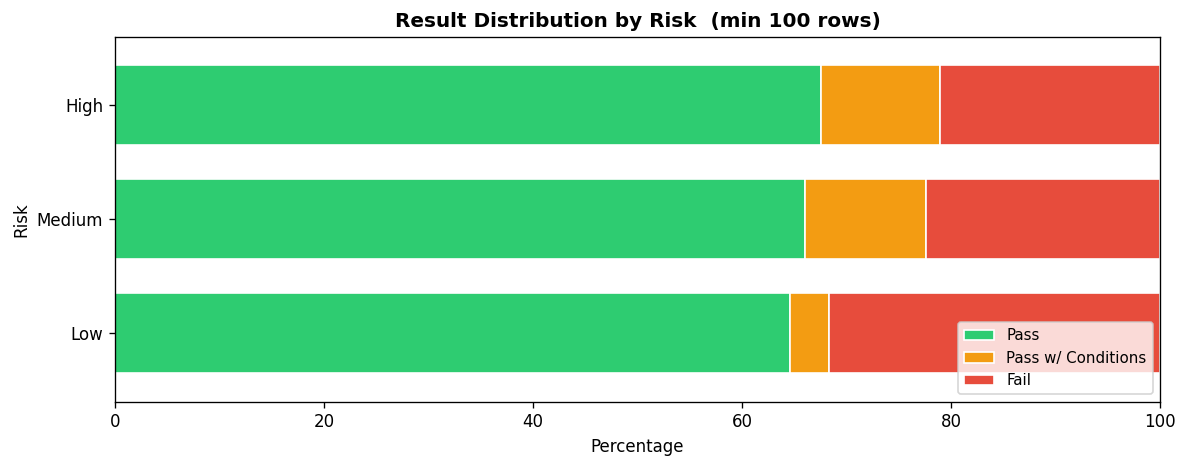

Results,Fail,Pass,Pass w/ Conditions
Risk,,,
Low,31.7,64.6,3.7
Medium,22.4,66.0,11.5
High,21.0,67.6,11.4


In [3]:
risk_ct = pass_rate_by('Risk', top_n=10)
risk_ct.round(1)

## 2 · Results vs Facility Type

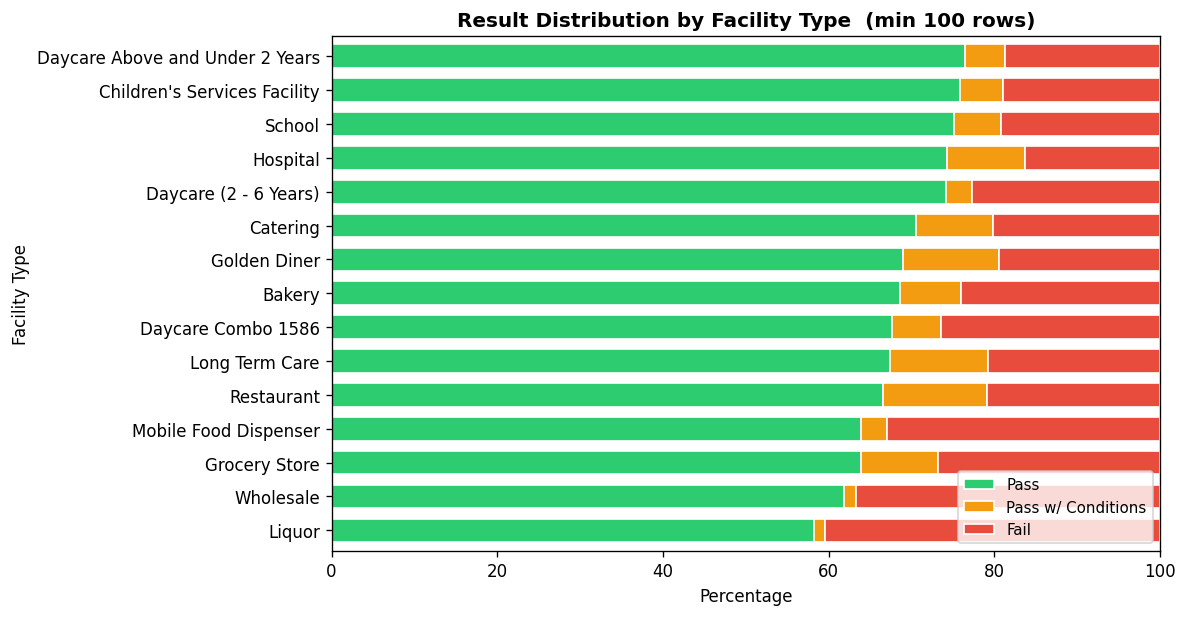

Results,Fail,Pass,Pass w/ Conditions
Facility Type,,,
Liquor,40.4,58.2,1.4
Wholesale,36.7,61.9,1.5
Grocery Store,26.8,63.8,9.4
Mobile Food Dispenser,33.0,63.9,3.2
Restaurant,20.9,66.5,12.5
Long Term Care,20.8,67.4,11.8
Daycare Combo 1586,26.5,67.6,5.9
Bakery,24.0,68.6,7.4
Golden Diner,19.5,69.0,11.5


In [4]:
fac_ct = pass_rate_by('Facility Type', top_n=15)
fac_ct.round(1)

## 3 · Results vs Inspection Type

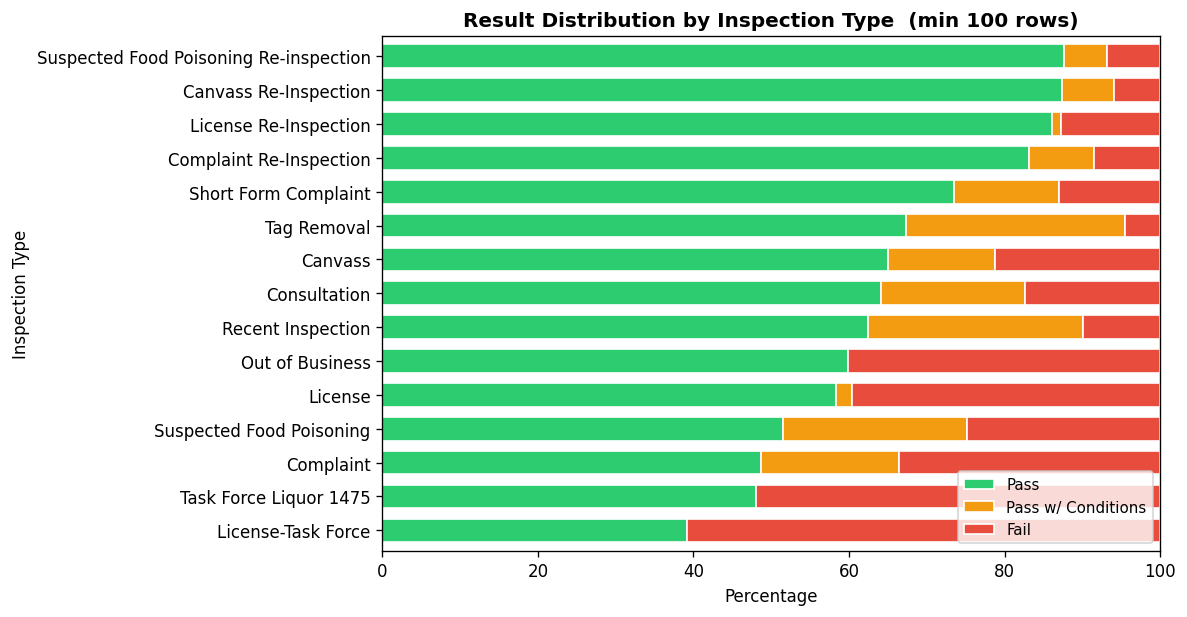

Results,Fail,Pass,Pass w/ Conditions
Inspection Type,,,
License-Task Force,60.9,39.1,0.0
Task Force Liquor 1475,52.0,48.0,0.0
Complaint,33.5,48.7,17.8
Suspected Food Poisoning,24.9,51.6,23.6
License,39.6,58.3,2.1
Out of Business,40.1,59.9,0.0
Recent Inspection,9.9,62.4,27.7
Consultation,17.4,64.1,18.6
Canvass,21.2,65.0,13.7


In [5]:
insp_ct = pass_rate_by('Inspection Type', top_n=15)
insp_ct.round(1)

## 4 · Results vs Community Area

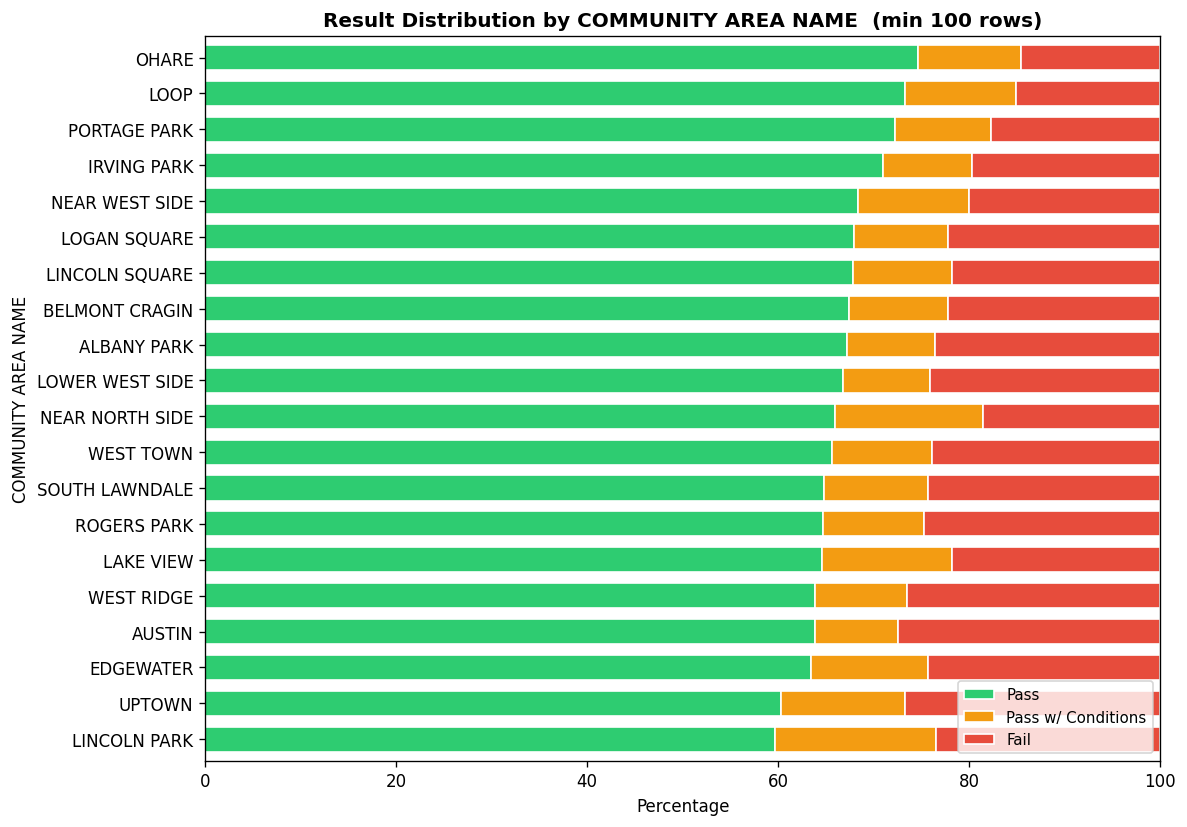

In [6]:
if 'COMMUNITY AREA NAME' in df.columns:
    ca_ct = pass_rate_by('COMMUNITY AREA NAME', top_n=20)
    ca_ct.round(1)

## 5 · Results vs Boolean flags

In [7]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    rows = []
    for col in bool_cols:
        for val in [True, False]:
            sub = df[df[col] == val]
            if len(sub) > 0:
                pass_rate = (sub[TARGET] == 'Pass').mean() * 100
                fail_rate = (sub[TARGET] == 'Fail').mean() * 100
                rows.append({'flag': col, 'value': val, 'n': len(sub),
                             'pass_rate': round(pass_rate, 1),
                             'fail_rate': round(fail_rate, 1)})
    flag_df = pd.DataFrame(rows)
    print('Pass/Fail rates by boolean flag values:')
    display(flag_df)

Pass/Fail rates by boolean flag values:


,flag,value,n,pass_rate,fail_rate
0,flag_non_il_state,False,137176,67.1,22.1
1,flag_non_chicago_city,True,149,69.8,22.1
2,flag_non_chicago_city,False,137027,67.1,22.1
3,flag_longitude_outside_typical_range,False,137176,67.1,22.1
4,violations_recorded,True,114101,63.0,24.1
5,violations_recorded,False,23075,86.9,12.5
6,license_matched,False,137176,67.1,22.1
7,has_prior_inspection,True,110027,69.2,18.7
8,has_prior_inspection,False,27149,58.3,35.7


## 6 · Results over time

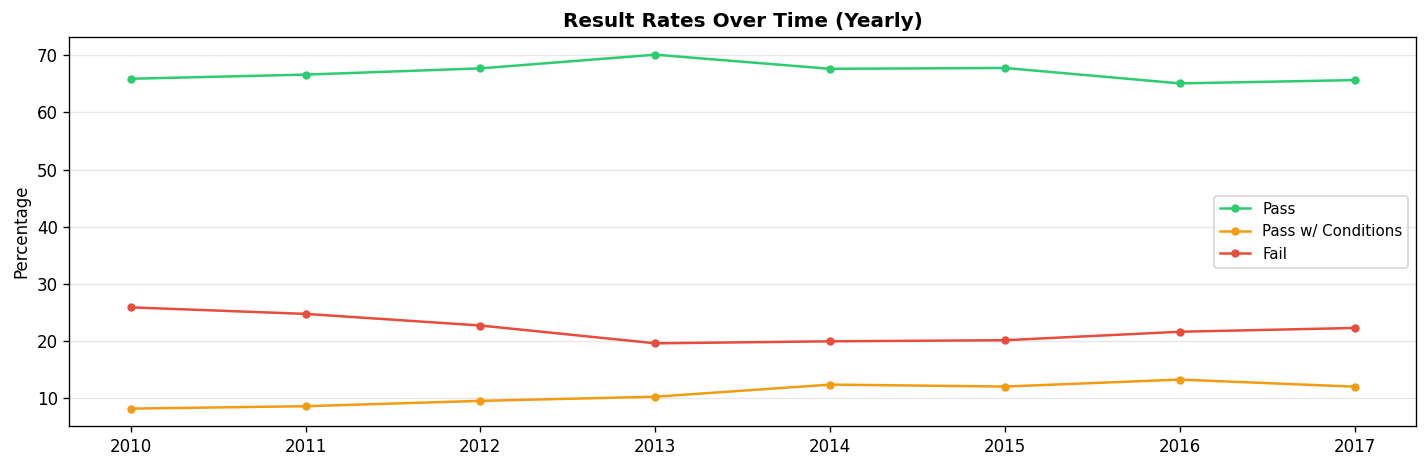

In [8]:
df['year'] = df['Inspection Date'].dt.year
yearly_rates = pd.crosstab(df['year'], df[TARGET], normalize='index').mul(100)

fig, ax = plt.subplots(figsize=(12, 4))
ordered = [c for c in ['Pass', 'Pass w/ Conditions', 'Fail'] if c in yearly_rates.columns]
colors = [T_COLORS[c] for c in ordered]
yearly_rates[ordered].plot(ax=ax, marker='o', markersize=4, linewidth=1.5, color=colors)
ax.set_title('Result Rates Over Time (Yearly)', fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xlabel('')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df.drop(columns='year', inplace=True)

## 7 · Numeric features vs target (box plots)

C:\Users\user\AppData\Local\Temp\ipykernel_28180\2922746896.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
C:\Users\user\AppData\Local\Temp\ipykernel_28180\2922746896.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
C:\Users\user\AppData\Local\Temp\ipykernel_28180\2922746896.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
C:\Users\user\AppData\Local\Temp\ipykernel_28180\2922746896.py:13: MatplotlibDepre

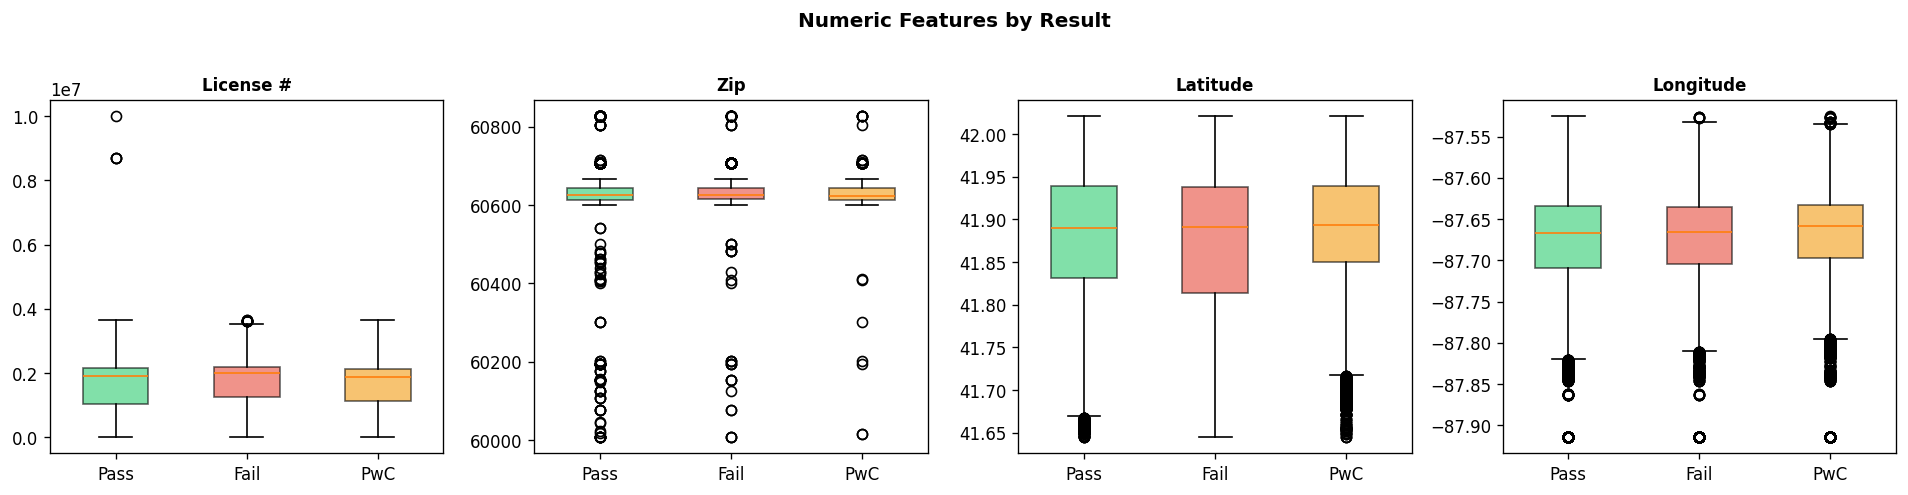

In [9]:
num_cols = df.select_dtypes(include='number').columns.tolist()
# Exclude ID-like columns
num_cols = [c for c in num_cols if 'ID' not in c.upper()]

if num_cols:
    n = len(num_cols)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, num_cols):
        data = [df.loc[df[TARGET]==lab, col].dropna() for lab in ['Pass','Fail','Pass w/ Conditions']]
        labels = ['Pass','Fail','PwC']
        bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
        for patch, color in zip(bp['boxes'], [T_COLORS['Pass'], T_COLORS['Fail'], T_COLORS['Pass w/ Conditions']]):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.set_title(col, fontweight='bold', fontsize=10)
    fig.suptitle('Numeric Features by Result', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 8 · Correlation heatmap (numeric features)

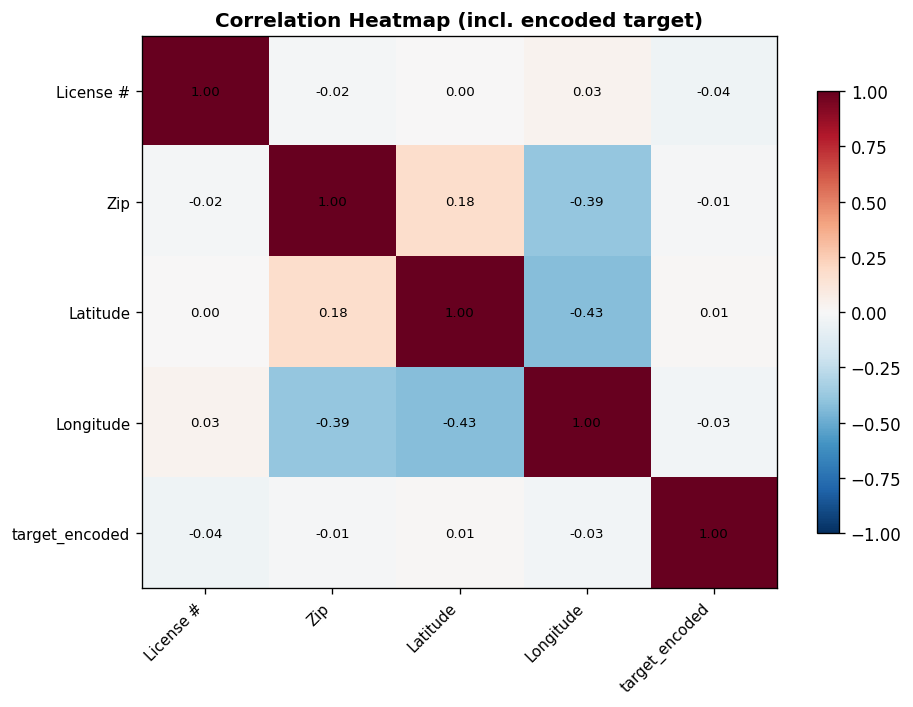

In [10]:
# Encode target as numeric for correlation
df_corr = df.copy()
target_map = {'Pass': 2, 'Pass w/ Conditions': 1, 'Fail': 0}
df_corr['target_encoded'] = df_corr[TARGET].map(target_map)

corr_cols = num_cols + ['target_encoded']
corr_cols = [c for c in corr_cols if c in df_corr.columns]

if len(corr_cols) > 1:
    corr = df_corr[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(corr_cols)))
    ax.set_yticks(range(len(corr_cols)))
    ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(corr_cols, fontsize=9)
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('Correlation Heatmap (incl. encoded target)', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9 · Key findings

Summarise the most important observations here after running the notebook:

1. **Strongest predictors**: _[fill in]_
2. **Surprising patterns**: _[fill in]_
3. **Features to engineer**: _[fill in]_
4. **Features to drop**: _[fill in]_
5. **Encoding strategy**: _[fill in]_